In [24]:
path = r"C:\Github Projects\SculpSoft_Projects\Heart Attack Prediction\data\raw\heart_attack_prediction_dataset.csv"

In [3]:
import os
import pandas as pd
pd.reset_option('display.max_columns')
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sb
%matplotlib inline
import plotly.express as px


In [26]:
df=pd.read_csv(path)

In [27]:
df.head()

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


In [28]:
df.shape

(8763, 26)

In [5]:
df.columns

Index(['Patient ID', 'Age', 'Sex', 'Cholesterol', 'Blood Pressure',
       'Heart Rate', 'Diabetes', 'Family History', 'Smoking', 'Obesity',
       'Alcohol Consumption', 'Exercise Hours Per Week', 'Diet',
       'Previous Heart Problems', 'Medication Use', 'Stress Level',
       'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides',
       'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Country',
       'Continent', 'Hemisphere', 'Heart Attack Risk'],
      dtype='object')

In [16]:
df["Heart Attack Risk"].value_counts()

Heart Attack Risk
0    5624
1    3139
Name: count, dtype: int64

In [ ]:
df.drop(columns=["Hemisphere","Continent","Country"],inplace=True)

In [33]:
df.drop(columns=["Patient ID"],inplace=True)

In [34]:
df.head()

,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,...,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk
0,67,Male,208,158/88,72,0,0,1,0,0,...,0,0,9,6.615001,261404,31.251233,286,0,6,0
1,21,Male,389,165/93,98,1,1,1,1,1,...,1,0,1,4.963459,285768,27.194973,235,1,7,0
2,21,Female,324,174/99,72,1,0,0,0,0,...,1,1,9,9.463426,235282,28.176571,587,4,4,0
3,84,Male,383,163/100,73,1,1,1,0,1,...,1,0,9,7.648981,125640,36.464704,378,3,4,0
4,66,Male,318,91/88,93,1,1,1,1,0,...,1,0,6,1.514821,160555,21.809144,231,1,5,0


In [32]:
df["Blood Pressure"].value_counts().sum()

8763

In [35]:
df[['Systolic BP', 'Diastolic BP']] = df['Blood Pressure'].str.split('/', expand=True).astype(float)
df.drop(columns=['Blood Pressure'], inplace=True)
df.head()

,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,...,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk,Systolic BP,Diastolic BP
0,67,Male,208,72,0,0,1,0,0,4.168189,...,9,6.615001,261404,31.251233,286,0,6,0,158.0,88.0
1,21,Male,389,98,1,1,1,1,1,1.813242,...,1,4.963459,285768,27.194973,235,1,7,0,165.0,93.0
2,21,Female,324,72,1,0,0,0,0,2.078353,...,9,9.463426,235282,28.176571,587,4,4,0,174.0,99.0
3,84,Male,383,73,1,1,1,0,1,9.828130,...,9,7.648981,125640,36.464704,378,3,4,0,163.0,100.0
4,66,Male,318,93,1,1,1,1,0,5.804299,...,6,1.514821,160555,21.809144,231,1,5,0,91.0,88.0


In [36]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Diet'] = le.fit_transform(df['Diet'])
df['Sex'] = le.fit_transform(df['Sex'])
df.head()

,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,...,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk,Systolic BP,Diastolic BP
0,67,1,208,72,0,0,1,0,0,4.168189,...,9,6.615001,261404,31.251233,286,0,6,0,158.0,88.0
1,21,1,389,98,1,1,1,1,1,1.813242,...,1,4.963459,285768,27.194973,235,1,7,0,165.0,93.0
2,21,0,324,72,1,0,0,0,0,2.078353,...,9,9.463426,235282,28.176571,587,4,4,0,174.0,99.0
3,84,1,383,73,1,1,1,0,1,9.828130,...,9,7.648981,125640,36.464704,378,3,4,0,163.0,100.0
4,66,1,318,93,1,1,1,1,0,5.804299,...,6,1.514821,160555,21.809144,231,1,5,0,91.0,88.0


In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df.drop(columns=['Heart Attack Risk']))
df_feat = pd.DataFrame(scaled_features, columns=df.columns[:-1])

In [38]:
df_feat.head()

,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,...,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk,Systolic BP
0,0.625557,0.658765,-0.641579,-0.147042,-1.369651,-0.986061,0.339157,-1.002857,-1.219867,-1.010838,...,-0.996696,1.234604,0.179251,1.280130,0.373454,-0.588539,-1.528843,-0.514750,0.870044,0.193782
1,-1.539322,0.658765,1.596895,1.118179,0.730113,1.014136,0.339157,0.997151,0.819762,-1.418027,...,-0.996696,-1.563129,-0.297225,1.582523,-0.268479,-0.816487,-1.090738,-0.011823,1.135714,0.534480
2,-1.539322,-1.517992,0.793023,-0.147042,0.730113,-0.986061,-2.948488,-1.002857,-1.219867,-1.372188,...,1.003315,1.234604,1.001031,0.955917,-0.113134,0.756800,0.223577,-1.520604,1.477290,0.943319
3,1.425621,0.658765,1.522691,-0.098380,0.730113,1.014136,0.339157,-1.002857,0.819762,-0.032188,...,-0.996696,1.234604,0.477557,-0.404902,1.198524,-0.177339,-0.214528,-1.520604,1.059809,1.011458
4,0.578495,0.658765,0.718820,0.874867,0.730113,1.014136,0.339157,0.997151,-1.219867,-0.727941,...,-0.996696,0.185454,-1.292170,0.028445,-1.120826,-0.834365,-1.090738,-1.017677,-1.672797,0.193782


In [46]:
df.dtypes

Age                                  int64
Sex                                  int32
Cholesterol                          int64
Heart Rate                           int64
Diabetes                             int64
Family History                       int64
Smoking                              int64
Obesity                              int64
Alcohol Consumption                  int64
Exercise Hours Per Week            float64
Diet                                 int32
Previous Heart Problems              int64
Medication Use                       int64
Stress Level                         int64
Sedentary Hours Per Day            float64
BMI                                float64
Triglycerides                        int64
Physical Activity Days Per Week      int64
Sleep Hours Per Day                  int64
Heart Attack Risk                    int64
Systolic BP                        float64
Diastolic BP                       float64
dtype: object

In [47]:
from imblearn.over_sampling import SMOTE
x=df.drop(columns=["Heart Attack Risk"])
y=df["Heart Attack Risk"]

smote=SMOTE(random_state=42)
x_resampled,y_resampled=smote.fit_resample(x,y)

c:\Users\admin\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [52]:
df.shape

(8763, 22)

In [57]:
x_resampled=pd.DataFrame(x_resampled)
y_resampled=pd.DataFrame(y_resampled)

In [61]:
df=pd.concat([x_resampled,y_resampled],axis=1)

In [62]:
df.head()

,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,...,Medication Use,Stress Level,Sedentary Hours Per Day,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Systolic BP,Diastolic BP,Heart Attack Risk
0,67,1,208,72,0,0,1,0,0,4.168189,...,0,9,6.615001,31.251233,286,0,6,158.0,88.0,0
1,21,1,389,98,1,1,1,1,1,1.813242,...,0,1,4.963459,27.194973,235,1,7,165.0,93.0,0
2,21,0,324,72,1,0,0,0,0,2.078353,...,1,9,9.463426,28.176571,587,4,4,174.0,99.0,0
3,84,1,383,73,1,1,1,0,1,9.828130,...,0,9,7.648981,36.464704,378,3,4,163.0,100.0,0
4,66,1,318,93,1,1,1,1,0,5.804299,...,0,6,1.514821,21.809144,231,1,5,91.0,88.0,0


In [ ]:
path1 = r"C:/Github Projects/SculpSoft_Projects/Heart Attack Prediction/data/processed/processed.csv"
df.to_csv(path1, index=False)

In [5]:
df=pd.read_csv("C:/Github Projects/SculpSoft_Projects/Heart Attack Prediction/data/processed/processed.csv")
df.head()

,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,...,Medication Use,Stress Level,Sedentary Hours Per Day,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Systolic BP,Diastolic BP,Heart Attack Risk
0,67,1,208,72,0,0,1,0,0,4.168189,...,0,9,6.615001,31.251233,286,0,6,158.0,88.0,0
1,21,1,389,98,1,1,1,1,1,1.813242,...,0,1,4.963459,27.194973,235,1,7,165.0,93.0,0
2,21,0,324,72,1,0,0,0,0,2.078353,...,1,9,9.463426,28.176571,587,4,4,174.0,99.0,0
3,84,1,383,73,1,1,1,0,1,9.828130,...,0,9,7.648981,36.464704,378,3,4,163.0,100.0,0
4,66,1,318,93,1,1,1,1,0,5.804299,...,0,6,1.514821,21.809144,231,1,5,91.0,88.0,0


In [49]:
df["Previous Heart Problems"].value_counts()

Previous Heart Problems
0    6282
1    4966
Name: count, dtype: int64

In [45]:
df.columns

Index(['Age', 'Sex', 'Cholesterol', 'Heart Rate', 'Diabetes', 'Family History',
       'Smoking', 'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week',
       'Diet', 'Previous Heart Problems', 'Medication Use', 'Stress Level',
       'Sedentary Hours Per Day', 'BMI', 'Triglycerides',
       'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Systolic BP',
       'Diastolic BP', 'Heart Attack Risk'],
      dtype='object')

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df.drop(columns=['Heart Attack Risk','Sex','Diabetes','Family History','Smoking','Obesity','Medication Use','Physical Activity Days Per Week','Previous Heart Problems']))


In [7]:
df1=df[['Heart Attack Risk','Sex','Diabetes','Family History','Smoking','Obesity','Medication Use','Physical Activity Days Per Week','Previous Heart Problems']]
df = pd.concat([pd.DataFrame(scaled_features),df1],axis=1)

In [56]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,12,Heart Attack Risk,Sex,Diabetes,Family History,Smoking,Obesity,Medication Use,Physical Activity Days Per Week,Previous Heart Problems
0,0.634518,-0.650746,-0.141987,-1.097948,-1.056104,-1.164193,1.322831,0.191794,0.384032,-0.594790,...,0.199912,0,1,0,0,1,0,0,0,0
1,-1.564545,1.593374,1.142389,0.910790,-1.477541,1.357198,-1.581349,-0.302219,-0.279648,-0.821256,...,0.549769,0,1,1,1,1,1,0,1,1
2,-1.564545,0.787475,-0.141987,-1.097948,-1.430097,0.096502,1.322831,1.043822,-0.119040,0.741804,...,0.969597,0,0,1,0,0,0,1,4,1
3,1.447215,1.518983,-0.092588,0.910790,-0.043211,-1.164193,1.322831,0.501081,1.237054,-0.186263,...,1.039568,0,1,1,1,1,0,0,3,1
4,0.586712,0.713084,0.895394,-1.097948,-0.763308,1.357198,0.233763,-1.333785,-1.160870,-0.839018,...,0.199912,0,1,1,1,1,1,0,1,1


In [8]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Heart Attack Risk'])
y = df['Heart Attack Risk']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.ensemble import RandomForestClassifier


rf_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2'],
    'bootstrap': [True, False],
    'class_weight': [None, 'balanced']
}

rf = RandomForestClassifier(random_state=42)
rf_gs = GridSearchCV(rf, rf_grid, cv=5, scoring='accuracy', n_jobs=-1)
rf_gs.fit(X_train, y_train)

print('Random Forest Best Params:', rf_gs.best_params_)
y_pred_rf = rf_gs.predict(X_test)
print('Random Forest Accuracy:', accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

c:\Users\admin\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
3600 fits failed out of a total of 10800.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2947 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\admin\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\admin\anaconda3\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "c:\Users\admin\anaconda3\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "c:\Users\admin\anaconda3\Lib\site-pa

Random Forest Best Params: {'bootstrap': True, 'class_weight': 'balanced', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Random Forest Accuracy: 0.6973333333333334
              precision    recall  f1-score   support

           0       0.66      0.80      0.73      1125
           1       0.75      0.60      0.66      1125

    accuracy                           0.70      2250
   macro avg       0.71      0.70      0.69      2250
weighted avg       0.71      0.70      0.69      2250



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report


y = df['Heart Attack Risk']
X = df.drop(columns=['Heart Attack Risk'])
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'solver': ['liblinear', 'lbfgs', 'saga', 'newton-cg', 'sag'],
    'max_iter': [100, 200, 500, 1000],
    'penalty': ['l2', 'none'],
    'fit_intercept': [True, False],
    'class_weight': [None, 'balanced']
}

logreg = LogisticRegression()
gs = GridSearchCV(logreg, grid, cv=5, scoring='accuracy', n_jobs=-1)
gs.fit(X_train, y_train)

print('Best Params:', gs.best_params_)
y_pred = gs.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_grid = {
    'n_neighbors': [1],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'leaf_size': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    'p': [1, 2],
    'metric': ['minkowski', 'euclidean', 'manhattan', 'chebyshev', 'wminkowski', 'seuclidean', 'mahalanobis']
}

knn = KNeighborsClassifier()
knn_gs = GridSearchCV(knn, knn_grid, cv=5, scoring='accuracy', n_jobs=-1)
knn_gs.fit(X_train, y_train)

print('KNN (k=1) Best Params:', knn_gs.best_params_)
y_pred_knn = knn_gs.predict(X_test)
print('KNN (k=1) Accuracy:', accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

c:\Users\admin\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
3000 fits failed out of a total of 7000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
76 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\admin\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\admin\anaconda3\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "c:\Users\admin\anaconda3\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "c:\Users\admin\anaconda3\Lib\site-packa

KNN (k=1) Best Params: {'algorithm': 'auto', 'leaf_size': 10, 'metric': 'minkowski', 'n_neighbors': 1, 'p': 1, 'weights': 'uniform'}
KNN (k=1) Accuracy: 0.7186666666666667
              precision    recall  f1-score   support

           0       0.80      0.58      0.67      1125
           1       0.67      0.85      0.75      1125

    accuracy                           0.72      2250
   macro avg       0.74      0.72      0.71      2250
weighted avg       0.74      0.72      0.71      2250

KNN (k=1) Accuracy: 0.7186666666666667
              precision    recall  f1-score   support

           0       0.80      0.58      0.67      1125
           1       0.67      0.85      0.75      1125

    accuracy                           0.72      2250
   macro avg       0.74      0.72      0.71      2250
weighted avg       0.74      0.72      0.71      2250



In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

rf = RandomForestClassifier(
    n_estimators=1500,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,
    class_weight=None,
    random_state=42,
 )
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print('Random Forest Accuracy:', accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7071111111111111
              precision    recall  f1-score   support

           0       0.68      0.79      0.73      1120
           1       0.75      0.62      0.68      1130

    accuracy                           0.71      2250
   macro avg       0.71      0.71      0.71      2250
weighted avg       0.71      0.71      0.71      2250



In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
 )
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
print('XGBoost Accuracy:', accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

c:\Users\admin\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:54:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.6675555555555556
              precision    recall  f1-score   support

           0       0.66      0.68      0.67      1120
           1       0.68      0.65      0.66      1130

    accuracy                           0.67      2250
   macro avg       0.67      0.67      0.67      2250
weighted avg       0.67      0.67      0.67      2250



In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

ada = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.3,
    random_state=42
 )
ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)
print('AdaBoost Accuracy:', accuracy_score(y_test, y_pred_ada))
print(classification_report(y_test, y_pred_ada))

AdaBoost Accuracy: 0.6253333333333333
              precision    recall  f1-score   support

           0       0.63      0.61      0.62      1120
           1       0.62      0.64      0.63      1130

    accuracy                           0.63      2250
   macro avg       0.63      0.63      0.63      2250
weighted avg       0.63      0.63      0.63      2250



KNN Accuracy (k=5): 0.6257777777777778
              precision    recall  f1-score   support

           0       0.67      0.49      0.57      1120
           1       0.60      0.76      0.67      1130

    accuracy                           0.63      2250
   macro avg       0.63      0.63      0.62      2250
weighted avg       0.63      0.63      0.62      2250



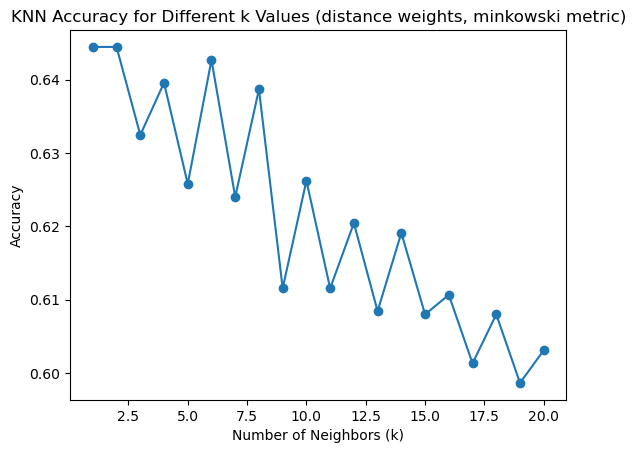

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report


X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)


knn = KNeighborsClassifier(n_neighbors=5, weights='distance', algorithm='auto', leaf_size=30, p=2, metric='minkowski')
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print('KNN Accuracy (k=5):', accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

import matplotlib.pyplot as plt
k_range = range(1, 21)
accuracies = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance', algorithm='auto', leaf_size=30, p=2, metric='minkowski')
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
plt.plot(k_range, accuracies, marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy for Different k Values (distance weights, minkowski metric)')
plt.show()

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

svm = SVC(kernel='poly', C=1.0, gamma='auto', random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print('SVM Accuracy:', accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
print('Naive Bayes Accuracy:', accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))


from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=None, min_samples_split=2, min_samples_leaf=1, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print('Decision Tree Accuracy:', accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

SVM Accuracy: 0.6293333333333333
              precision    recall  f1-score   support

           0       0.63      0.61      0.62      1120
           1       0.63      0.65      0.64      1130

    accuracy                           0.63      2250
   macro avg       0.63      0.63      0.63      2250
weighted avg       0.63      0.63      0.63      2250

Naive Bayes Accuracy: 0.6248888888888889
              precision    recall  f1-score   support

           0       0.61      0.66      0.64      1120
           1       0.64      0.59      0.61      1130

    accuracy                           0.62      2250
   macro avg       0.63      0.63      0.62      2250
weighted avg       0.63      0.62      0.62      2250

Decision Tree Accuracy: 0.5826666666666667
              precision    recall  f1-score   support

           0       0.58      0.56      0.57      1120
           1       0.58      0.60      0.59      1130

    accuracy                           0.58      2250
   macro av

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Ensure all column names are strings for sklearn compatibility
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

# Use best parameters found:
knn_best = KNeighborsClassifier(
    n_neighbors=1,
    weights='uniform',
    algorithm='auto',
    leaf_size=10,
    p=1,
    metric='minkowski'
 )
knn_best.fit(X_train, y_train)
y_pred_knn_best = knn_best.predict(X_test)
print('KNN (k=1, best params) Accuracy:', accuracy_score(y_test, y_pred_knn_best))
print(classification_report(y_test, y_pred_knn_best))

KNN (k=1, best params) Accuracy: 0.6648888888888889
              precision    recall  f1-score   support

           0       0.73      0.52      0.61      1120
           1       0.63      0.81      0.71      1130

    accuracy                           0.66      2250
   macro avg       0.68      0.66      0.66      2250
weighted avg       0.68      0.66      0.66      2250



In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

rf_criterion = RandomForestClassifier(
    n_estimators=1500,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,
    class_weight=None,
    random_state=42,
    criterion='gini' 
 )
rf_criterion.fit(X_train, y_train)
y_pred_rf_criterion = rf_criterion.predict(X_test)
print('Random Forest (criterion=entropy) Accuracy:', accuracy_score(y_test, y_pred_rf_criterion))
print(classification_report(y_test, y_pred_rf_criterion))

Random Forest (criterion=entropy) Accuracy: 0.7071111111111111
              precision    recall  f1-score   support

           0       0.68      0.79      0.73      1120
           1       0.75      0.62      0.68      1130

    accuracy                           0.71      2250
   macro avg       0.71      0.71      0.71      2250
weighted avg       0.71      0.71      0.71      2250



In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Ensure all column names are strings for sklearn compatibility
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

rf_cv_grid = {
    'n_estimators': [500, 1000, 1500],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True],
    'class_weight': [None],
    'criterion': ['gini', 'entropy', 'log_loss']
}

rf_cv = RandomForestClassifier(random_state=42)
rf_cv_gs = GridSearchCV(rf_cv, rf_cv_grid, cv=5, scoring='accuracy', n_jobs=-1)
rf_cv_gs.fit(X_train, y_train)

print('Random Forest (CV) Best Params:', rf_cv_gs.best_params_)
y_pred_rf_cv = rf_cv_gs.predict(X_test)
print('Random Forest (CV) Accuracy:', accuracy_score(y_test, y_pred_rf_cv))
print(classification_report(y_test, y_pred_rf_cv))

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report

# Ensure all column names are strings for sklearn compatibility
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

rf_cv_only = RandomForestClassifier(
    n_estimators=1500,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,
    class_weight=None,
    random_state=42,
    criterion='gini'  
 )

cv_scores = cross_val_score(rf_cv_only, X_train, y_train, cv=2, scoring='accuracy', n_jobs=-1)
print('Random Forest (CV only) Mean Accuracy:', cv_scores.mean())
print('Random Forest (CV only) Fold Accuracies:', cv_scores)

rf_cv_only.fit(X_train, y_train)
y_pred_rf_cv_only = rf_cv_only.predict(X_test)
print('Random Forest (CV only) Test Accuracy:', accuracy_score(y_test, y_pred_rf_cv_only))
print(classification_report(y_test, y_pred_rf_cv_only))

Random Forest (CV only) Mean Accuracy: 0.6654812180484553
Random Forest (CV only) Fold Accuracies: [0.66059124 0.67037119]
Random Forest (CV only) Test Accuracy: 0.7071111111111111
              precision    recall  f1-score   support

           0       0.68      0.79      0.73      1120
           1       0.75      0.62      0.68      1130

    accuracy                           0.71      2250
   macro avg       0.71      0.71      0.71      2250
weighted avg       0.71      0.71      0.71      2250

Random Forest (CV only) Test Accuracy: 0.7071111111111111
              precision    recall  f1-score   support

           0       0.68      0.79      0.73      1120
           1       0.75      0.62      0.68      1130

    accuracy                           0.71      2250
   macro avg       0.71      0.71      0.71      2250
weighted avg       0.71      0.71      0.71      2250



In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report

# Ensure all column names are strings for sklearn compatibility
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

lgbm = LGBMClassifier(
    n_estimators=8000,
    max_depth=15,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
 )
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)
print('LightGBM Accuracy:', accuracy_score(y_test, y_pred_lgbm))
print(classification_report(y_test, y_pred_lgbm))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4494, number of negative: 4504
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000903 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1971
[LightGBM] [Info] Number of data points in the train set: 8998, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499444 -> initscore=-0.002223
[LightGBM] [Info] Start training from score -0.002223
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g